#MINOR PROJECT 3
##OPTION 2: STUDENT PERFORMANCE AND ATTENDANCE ANALYZER
##1. PROBLEM STATEMENT
Educational institutions need to analyze student performance and attendance to identify patterns, weak areas, and overall outcomes.This project analyzes academic records to support data-driven decisions.By evaluating how attendance categories impact final grades and how performance varies across different subjects, we aim to uncover actionable insights to improve student success rates.


In [17]:
from google.colab import files
uploaded = files.upload()

Saving Data Science March Minor Project_2 Dataset_1.xlsx to Data Science March Minor Project_2 Dataset_1 (1).xlsx


In [18]:
#IMPORT IMPORTANT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#import theme
sns.set_theme(style = "whitegrid")
df = pd.read_excel('Data Science March Minor Project_2 Dataset_1.xlsx')
# Show the first few rows to make sure it works
df.head()


,Name,Gender,Phone Number,State Of Birth,Email,Student ID,Qualification,Course,Semester,GPA,CGPA,Raised Hands,Visited Resource,Announcements Visited,Discussion,Absence Days Under-7
0,Lum Meu Mel,F,010-981 7433,Penang,meumel32@yahoo.com,21PMD30001,Degree,Hotel Management,S,3.958,3.817,43,47,42,36,1
1,Eric Hew Law Toh,M,019-752 8050,Kedah,law03toh@hotmail.com,21PMD30002,Diploma,Accounting,F,3.065,3.182,9,15,13,10,0
2,Hao Lin Min,F,019-455 0808,Perak,hoa32@crooks.org,21PMD30003,Degree,Information Technology,S,2.984,3.091,7,12,11,9,0
3,Cheng Zheng Xun,M,016-375 8448,Penang,zheng1xun@gmail.com,21PMD30004,Diploma,Computer Science,F,2.820,2.606,8,6,7,8,0
4,Eunice Cheong En Hui,F,014-550 5401,Kedah,enhui12@gmail.com,21PMD30005,Degree,Business,F,3.621,3.752,31,29,28,29,1


In [19]:
#data inspection
df.describe()

,GPA,CGPA,Visited Resource,Announcements Visited,Discussion,Absence Days Under-7
count,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000
mean,3.351890,3.297080,24.93000,24.570000,24.620000,0.740000
std,0.359059,0.386223,12.07406,12.221239,12.933224,0.440844
min,2.323000,2.319000,3.00000,3.000000,0.000000,0.000000
25%,3.116000,3.086750,13.75000,12.000000,11.000000,0.000000
50%,3.333000,3.335000,26.00000,25.000000,25.500000,1.000000
75%,3.612750,3.562000,34.25000,35.000000,35.250000,1.000000
max,4.000000,3.939000,48.00000,50.000000,49.000000,1.000000


##DATA CLEANING OPERATIONS


In [20]:
print("Dataset Dimensions:",df.shape)
print("\nDataset Columns:\n", df.columns)
print("\ndata Types:\n",df.dtypes)
print("\nMissing Values Count:\n",df.isnull().sum())
df.head()

Dataset Dimensions: (100, 16)

Dataset Columns:
 Index(['Name', 'Gender', 'Phone Number', 'State Of Birth', 'Email',
       'Student ID', 'Qualification', 'Course', 'Semester', 'GPA', 'CGPA',
       'Raised Hands', 'Visited Resource', 'Announcements Visited',
       'Discussion', 'Absence Days Under-7'],
      dtype='object')

data Types:
 Name                      object
Gender                    object
Phone Number              object
State Of Birth            object
Email                     object
Student ID                object
Qualification             object
Course                    object
Semester                  object
GPA                      float64
CGPA                     float64
Raised Hands              object
Visited Resource           int64
Announcements Visited      int64
Discussion                 int64
Absence Days Under-7       int64
dtype: object

Missing Values Count:
 Name                     0
Gender                   0
Phone Number             0
State Of Bi

,Name,Gender,Phone Number,State Of Birth,Email,Student ID,Qualification,Course,Semester,GPA,CGPA,Raised Hands,Visited Resource,Announcements Visited,Discussion,Absence Days Under-7
0,Lum Meu Mel,F,010-981 7433,Penang,meumel32@yahoo.com,21PMD30001,Degree,Hotel Management,S,3.958,3.817,43,47,42,36,1
1,Eric Hew Law Toh,M,019-752 8050,Kedah,law03toh@hotmail.com,21PMD30002,Diploma,Accounting,F,3.065,3.182,9,15,13,10,0
2,Hao Lin Min,F,019-455 0808,Perak,hoa32@crooks.org,21PMD30003,Degree,Information Technology,S,2.984,3.091,7,12,11,9,0
3,Cheng Zheng Xun,M,016-375 8448,Penang,zheng1xun@gmail.com,21PMD30004,Diploma,Computer Science,F,2.820,2.606,8,6,7,8,0
4,Eunice Cheong En Hui,F,014-550 5401,Kedah,enhui12@gmail.com,21PMD30005,Degree,Business,F,3.621,3.752,31,29,28,29,1


#EXPLORATORY DATA ANALYSIS,SUMMARY STATISTICS AND AGGREGATIONS

In [21]:
#Summary statistics for all numerical features (Marks, etc.)
display(df.describe())
#Category-wise distribution to see how many students are in each group
display(df.value_counts(subset=['Subject', 'Attendance_Category'] if 'Attendance_Category' in df.columns else None))

,GPA,CGPA,Visited Resource,Announcements Visited,Discussion,Absence Days Under-7
count,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000
mean,3.351890,3.297080,24.93000,24.570000,24.620000,0.740000
std,0.359059,0.386223,12.07406,12.221239,12.933224,0.440844
min,2.323000,2.319000,3.00000,3.000000,0.000000,0.000000
25%,3.116000,3.086750,13.75000,12.000000,11.000000,0.000000
50%,3.333000,3.335000,26.00000,25.000000,25.500000,1.000000
75%,3.612750,3.562000,34.25000,35.000000,35.250000,1.000000
max,4.000000,3.939000,48.00000,50.000000,49.000000,1.000000


,,,,,,,,,,,,,,,,count
Name,Gender,Phone Number,State Of Birth,Email,Student ID,Qualification,Course,Semester,GPA,CGPA,Raised Hands,Visited Resource,Announcements Visited,Discussion,Absence Days Under-7,
Alfred Soon Hong Bin,M,012-502 9952,Perak,alfredsoon@gmail.com,21PMD30100,Diploma,Computer Science,S,3.212,3.302,27,26,26,28,1,1
Ang Cheng Hao,M,017-212 7804,Kedah,chenghao@yahoo.com,21PMD30076,Diploma,Information Technology,F,3.134,3.232,25,27,25,26,1,1
Ang Jia Le,M,015-614 1573,Kedah,jiale12@gmail.com,21PMD30036,Diploma,Accounting,F,3.641,3.164,25,21,21,26,1,1
Brendan Lee Yong Hui,M,015-172 2388,Kedah,yonghui1211@yahoo.com,21PMD30015,Degree,Accounting,S,3.265,3.332,18,19,16,17,1,1
Bryan Goh Yi De,M,019-567 3295,Penang,deyigoh@gmail.com,21PMD30095,Degree,Marketing,F,3.012,2.910,7,10,9,6,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zhong Ming Hui,F,010-032 4692,Perak,minghui04@hotmail.com,21PMD30082,Degree,Information Technology,S,3.342,3.326,32,33,32,34,1,1
Zhong Zhi Hui,F,019-726 3159,Perak,zhihui@yahoo.com,21PMD30054,Degree,Information Technology,F,2.830,2.871,13,15,14,14,1,1
Zhuang Rui En,F,017-158 2020,Perak,ruien@yahoo.com,21PMD30081,Diploma,Information Technology,F,3.534,3.507,31,32,32,36,1,1


##DATA VISUALIZATION
We utilize Matplotlib and Seaborn to build graphs that illustrate marks distribution, subject metrics, and attendance behaviors

In [22]:
df.columns = df.columns.str.strip()

/tmp/ipykernel_1493/1819985657.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Course', y='CGPA', palette='Set2')
/tmp/ipykernel_1493/1819985657.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Absence Days Under-7', y='CGPA', estimator=np.mean, errorbar=None, palette='viridis')


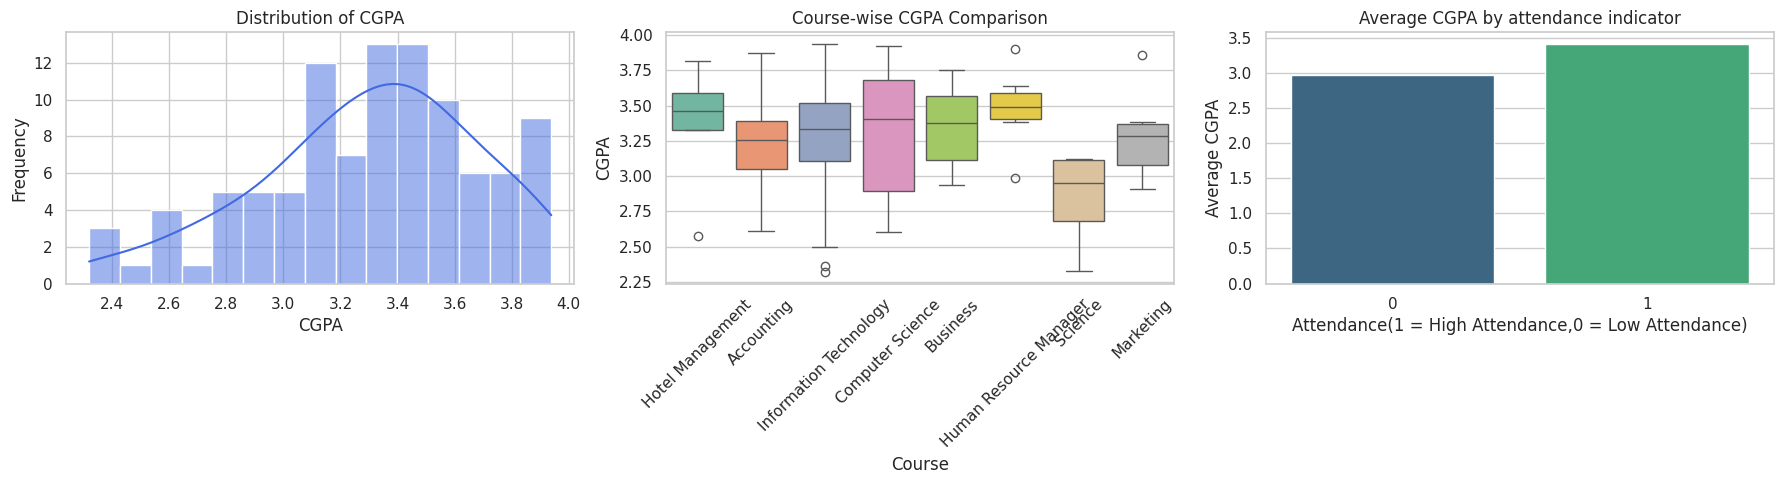

In [23]:
#generating charts
plt.figure(figsize=(18, 5))
#Histogram for mark distribution
plt.subplot(1, 3, 1)
sns.histplot(data=df, x='CGPA', kde=True, color='royalblue',bins=15)
plt.title('Distribution of CGPA')
plt.xlabel('CGPA')
plt.ylabel('Frequency')
plt.subplot(1, 3, 2)
sns.boxplot(data=df, x='Course', y='CGPA', palette='Set2')
plt.title('Course-wise CGPA Comparison')
plt.xticks(rotation=45)
plt.subplot(1, 3, 3)
sns.barplot(data=df, x='Absence Days Under-7', y='CGPA', estimator=np.mean, errorbar=None, palette='viridis')
plt.title('Average CGPA by attendance indicator')
plt.xlabel('Attendance(1 = High Attendance,0 = Low Attendance)')
plt.ylabel('Average CGPA')
plt.tight_layout()
plt.show()




## 5. Conclusions and Academic Insights

Based on the generated outputs and plots, we can draw the following conclusions:

1.CGPA Distribution: The student cohort's overall CGPA distribution displays where performance metrics cluster, helping administrators determine if the overall grade trend points towards a strong performance curve.

2.Course-wise Variance:The box plot highlights different performance metrics across streams (e.g., Information Technology, Computer Science, Business). This highlights specific paths where performance levels vary, signifying where modified academic resources might be needed.

3.Attendance vs. Performance:The attendance chart underscores the academic impact of presence. Students with regular attendance metrics (Indicator 1) show higher average CGPA trends compared to those with higher absenteeism patterns (Indicator 0), supporting classroom presence policies.

#